<a href="https://colab.research.google.com/github/Dario-Fajardo/TFG-Protocolo-de-votacion-electronica-cuantica/blob/main/quantum_voting_qss_ch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sistema de Votación Cuántica con Compartición de Secretos (QSS) - Variante CH

Sistema de **Votación Binaria Cuántica** usando **Compartición de Secretos Cuántica (QSS)** con Qiskit.

**Variante Mejorada**: Rotación de base controlada para mitigación de vulnerabilidad de fase en base Z.

## Componentes Principales:
- **q_voto**: Qubit del votante (codifica el voto)
- **q_v**: Qubit del canal entrelazado (votante)
- **q_c**: Qubit del Controlador
- **q_t**: Qubit del Escrutador

## Registros Clásicos:
- **c_voter[2]**: 2 bits de medición (votante)
- **c_controller[1]**: 1 bit del Controlador (base Z)
- **c_final[1]**: 1 bit del resultado

## Roles:
- **Votante**: Prepara y teletransporta el voto
- **Controlador**: Mide en base Z y coopera (sin rotación Hadamard)
- **Escrutador**: Aplica correcciones adaptativas y Hadamard condicional

## Mejora Principal:
La puerta Hadamard Controlada (CH) entre el Controlador (C) y el Tallyman (T) implementa una rotación de base condicional que mitiga la vulnerabilidad de fase.

## Sección 1: Importar Librerías

In [ ]:
!pip install qiskit qiskit-aer qiskit-ibm-runtime pylatexenc

In [ ]:
# Import required Qiskit modules
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, circuit_drawer
import matplotlib.pyplot as plt
import numpy as np

# Print configuration information
print("=" * 80)
print("IMPORTADAS DEPENDENCIAS")
print("=" * 80)

IMPORTADAS DEPENDENCIAS


## Sección 2: Definir la Arquitectura del Circuito

In [ ]:
# Create quantum registers
q_voto = QuantumRegister(1, 'q_voto')      # Voter's secret qubit
q_v = QuantumRegister(1, 'q_v')            # Voter's qubit for entangled channel
q_c = QuantumRegister(1, 'q_c')            # Controller's qubit
q_t = QuantumRegister(1, 'q_t')            # Tallyman's qubit

# Create classical registers
c_voter = ClassicalRegister(2, 'c_voter')   # 2 bits for voter's measurements (c0, c1)
c_controller = ClassicalRegister(1, 'c_controller')  # 1 bit for controller (c2)
c_final = ClassicalRegister(1, 'c_final')   # 1 bit for final verification

# Create quantum circuit
circuit = QuantumCircuit(q_voto, q_v, q_c, q_t, c_voter, c_controller, c_final)
circuit.name = "Quantum Binary Voting System (QSS) - Controlled Hadamard Variant"

# Print circuit information
print("\nQuantum Circuit Architecture:")
print(f"  Total Qubits: {circuit.num_qubits}")
print(f"  Total Classical Bits: {circuit.num_clbits}")
print(f"  Quantum Registers: q_voto, q_v, q_c, q_t")
print(f"  Classical Registers: c_voter(2), c_controller(1), c_final(1)")


Quantum Circuit Architecture:
  Total Qubits: 4
  Total Classical Bits: 4
  Quantum Registers: q_voto, q_v, q_c, q_t
  Classical Registers: c_voter(2), c_controller(1), c_final(1)


## Sección 3: Preparar Canal Bell y Puerta CH (Hadamard Controlada)

Se crea un estado de Bell entre q_v (Votante) y q_t (Tallyman):
$$|\Phi^+\rangle_{vT} = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$$

Luego se aplica una puerta Hadamard Controlada (CH) entre el Controlador (q_c) y el Tallyman (q_t) para la rotación de base condicional.

In [ ]:
# ============================================================================
# PASO 1: PREPARAR CANAL BELL Y APLICAR HADAMARD CONTROLADA
# ============================================================================

print("\n" + "="*80)
print("PASO 1: Preparar canal Bell entre votante (v) y tallyman (t)")
print("="*80)

# Crear estado de Bell |Phi+> entre q_v y q_t
# Hadamard en q_v
circuit.h(q_v[0])
print("✓ Puerta H en q_v")

# CNOT: q_v controla q_t
circuit.cx(q_v[0], q_t[0])
print("✓ CNOT(q_v → q_t) - Crear estado Bell")

circuit.barrier()
print("✓ Estado Bell |Phi+⟩ creado entre q_v y q_t")

# Aplicar Hadamard Controlada (CH) entre Controlador (q_c) y Tallyman (q_t)
print("\nAplicando Hadamard Controlada (CH)...")
circuit.h(q_c[0])  # Hadamard en el controlador para preparar superposición
circuit.ch(q_c[0], q_t[0])
print("✓ Puerta CH(q_c → q_t) aplicada")
print("  Esta puerta implementa rotación de base condicional")

circuit.barrier()
print("✓ Canal cuántico preparado con protección CH")


PASO 1: Preparar canal Bell entre votante (v) y tallyman (t)
✓ Puerta H en q_v
✓ CNOT(q_v → q_t) - Crear estado Bell
✓ Estado Bell |Phi+⟩ creado entre q_v y q_t

Aplicando Hadamard Controlada (CH)...
✓ Puerta CH(q_c → q_t) aplicada
  Esta puerta implementa rotación de base condicional
✓ Canal cuántico preparado con protección CH


## Sección 4: Preparar Superposición del Voto

Usando rotación RY con ángulo θ = π/4:

$$
R_y(\theta)=
\begin{pmatrix}
\cos(\theta/2) & -\sin(\theta/2) \\
\sin(\theta/2) & \cos(\theta/2)
\end{pmatrix}
$$

Estado: $$\cos(\pi/8)|0\rangle + \sin(\pi/8)|1\rangle$$

Probabilidades:
- P(0) ≈ 0.853 (85.3%) → Voto por SÍ
- P(1) ≈ 0.147 (14.7%) → Voto por NO

In [ ]:
# ============================================================================
# PASO 2: PREPARAR VOTO
# ============================================================================

print("\nPASO 2: Preparación del voto")
print("-" * 80)

# Rotación RY con ángulo π/4
vote_angle = np.pi / 4
circuit.ry(vote_angle, q_voto[0])

print(f"✓ RY({vote_angle:.4f}) en q_voto")
print(f"  Estado: cos(π/8)|0⟩ + sin(π/8)|1⟩")
print(f"  P(0)≈{pow(np.cos(np.pi/8), 2):.3f}, P(1)≈{pow(np.sin(np.pi/8), 2):.3f}")

circuit.barrier()


PASO 2: Preparación del voto
--------------------------------------------------------------------------------
✓ RY(0.7854) en q_voto
  Estado: cos(π/8)|0⟩ + sin(π/8)|1⟩
  P(0)≈0.854, P(1)≈0.146


CircuitInstruction(operation=Instruction(name='barrier', num_qubits=4, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "q_voto"), index=0>, <Qubit register=(1, "q_v"), index=0>, <Qubit register=(1, "q_c"), index=0>, <Qubit register=(1, "q_t"), index=0>), clbits=())

## Sección 5: Teletransporte del Voto (Lado Votante)

El voto se teletransporta de q_voto a q_v mediante:
1. CNOT(q_voto → q_v): Entrelazar el voto con el canal
2. Hadamard(q_voto): Finalizar el teletransporte

Resultado: q_v contiene el voto completo, q_voto pierde el voto.

In [ ]:
# ============================================================================
# PASO 3: TELETRANSPORTE
# ============================================================================

print("\nPASO 3: Teletransporte - Medición de Bell")
print("-" * 80)

# CNOT: q_voto controla q_v
circuit.cx(q_voto[0], q_v[0])
print("✓ CNOT(q_voto → q_v)")

# Hadamard en q_voto
circuit.h(q_voto[0])
print("✓ Hadamard en q_voto")

circuit.barrier()


PASO 3: Teletransporte - Medición de Bell
--------------------------------------------------------------------------------
✓ CNOT(q_voto → q_v)
✓ Hadamard en q_voto


CircuitInstruction(operation=Instruction(name='barrier', num_qubits=4, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "q_voto"), index=0>, <Qubit register=(1, "q_v"), index=0>, <Qubit register=(1, "q_c"), index=0>, <Qubit register=(1, "q_t"), index=0>), clbits=())

## Sección 6: Medir Qubits del Votante

Medición en base computacional:
- c_voter[0]: Resultado de medir q_voto
- c_voter[1]: Resultado de medir q_v

Estos 2 bits clásicos codifican la información para reconstruir el voto.

In [ ]:
# ============================================================================
# PASO 4: MEDICIÓN DEL VOTANTE
# ============================================================================

print("\nPASO 4: Medición del votante")
print("-" * 80)

# Medir q_voto y q_v
circuit.measure(q_voto[0], c_voter[0])
circuit.measure(q_v[0], c_voter[1])

print("✓ Medir q_voto → c_voter[0]")
print("✓ Medir q_v → c_voter[1]")

circuit.barrier()


PASO 4: Medición del votante
--------------------------------------------------------------------------------
✓ Medir q_voto → c_voter[0]
✓ Medir q_v → c_voter[1]


CircuitInstruction(operation=Instruction(name='barrier', num_qubits=4, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "q_voto"), index=0>, <Qubit register=(1, "q_v"), index=0>, <Qubit register=(1, "q_c"), index=0>, <Qubit register=(1, "q_t"), index=0>), clbits=())

## Sección 7: Medición del Controlador en Base Z

**VARIANTE MEJORADA**: El Controlador mide directamente en base Z sin aplicar rotación Hadamard:
- Medición proyectiva estándar en base computacional Z
- Genera el bit clásico M_C

Este bit será utilizado por el Tallyman para aplicar la corrección Hadamard condicional.

In [ ]:
# ============================================================================
# PASO 5: MEDICIÓN DEL CONTROLADOR (BASE Z - VARIANTE MEJORADA)
# ============================================================================

print("\nPASO 5: Medición del Controlador (base Z)")
print("-" * 80)

# VARIANTE: Sin Hadamard previo - medición directa en base Z
# Medir q_c directamente en base Z
circuit.measure(q_c[0], c_controller[0])
print("✓ Medir q_c → c_controller[0] (base Z, sin rotación)")
print("  El bit M_C será usado para corrección adaptativa por el Tallyman")

circuit.barrier()


PASO 5: Medición del Controlador (base Z)
--------------------------------------------------------------------------------
✓ Medir q_c → c_controller[0] (base Z, sin rotación)
  El bit M_C será usado para corrección adaptativa por el Tallyman


CircuitInstruction(operation=Instruction(name='barrier', num_qubits=4, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "q_voto"), index=0>, <Qubit register=(1, "q_v"), index=0>, <Qubit register=(1, "q_c"), index=0>, <Qubit register=(1, "q_t"), index=0>), clbits=())

## Sección 8: Correcciones Pauli y Hadamard Condicional del Tallyman

El Escrutador aplica:
1. **Correcciones Pauli estándar** basadas en mediciones del Votante
2. **Hadamard Condicional**: Si M_C = 1, aplica H en q_t para deshacer la rotación CH y recuperar ortogonalidad

Esta estrategia adaptativa mitiga la vulnerabilidad de fase en la base Z.

In [ ]:
# ============================================================================
# PASO 6: CORRECCIONES PAULI Y HADAMARD CONDICIONAL (TALLYMAN)
# ============================================================================

print("\nPASO 6: Correcciones adaptativas del Tallyman")
print("-" * 80)

# VARIANTE MEJORADA: Hadamard condicional basado en M_C
# Si M_C = 1, aplicar Hadamard en q_t para deshacer la rotación CH
circuit.ch(q_c[0], q_t[0])
print("✓ H condicional basado en c_controller[0] (M_C)")
print("  Si M_C=1: deshace la rotación CH y recupera ortogonalidad de papeleta")

# Correcciones Pauli estándar basadas en mediciones del Votante
circuit.cz(q_voto[0], q_t[0])
print("✓ Z condicional basado en c_voter[0]")

circuit.cx(q_v[0], q_t[0])
print("✓ X condicional basado en c_voter[1]")


circuit.barrier()

# Medición final
circuit.measure(q_t[0], c_final[0])

print("✓ Medir q_t → c_final[0] (resultado final)")
circuit.barrier()



PASO 6: Correcciones adaptativas del Tallyman
--------------------------------------------------------------------------------
✓ H condicional basado en c_controller[0] (M_C)
  Si M_C=1: deshace la rotación CH y recupera ortogonalidad de papeleta
✓ Z condicional basado en c_voter[0]
✓ X condicional basado en c_voter[1]
✓ Medir q_t → c_final[0] (resultado final)


CircuitInstruction(operation=Instruction(name='barrier', num_qubits=4, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "q_voto"), index=0>, <Qubit register=(1, "q_v"), index=0>, <Qubit register=(1, "q_c"), index=0>, <Qubit register=(1, "q_t"), index=0>), clbits=())

## Sección 9: Visualizar el Circuito

Representación visual del circuito cuántico completo con la variante mejorada.


VISUALIZACIÓN DEL CIRCUITO


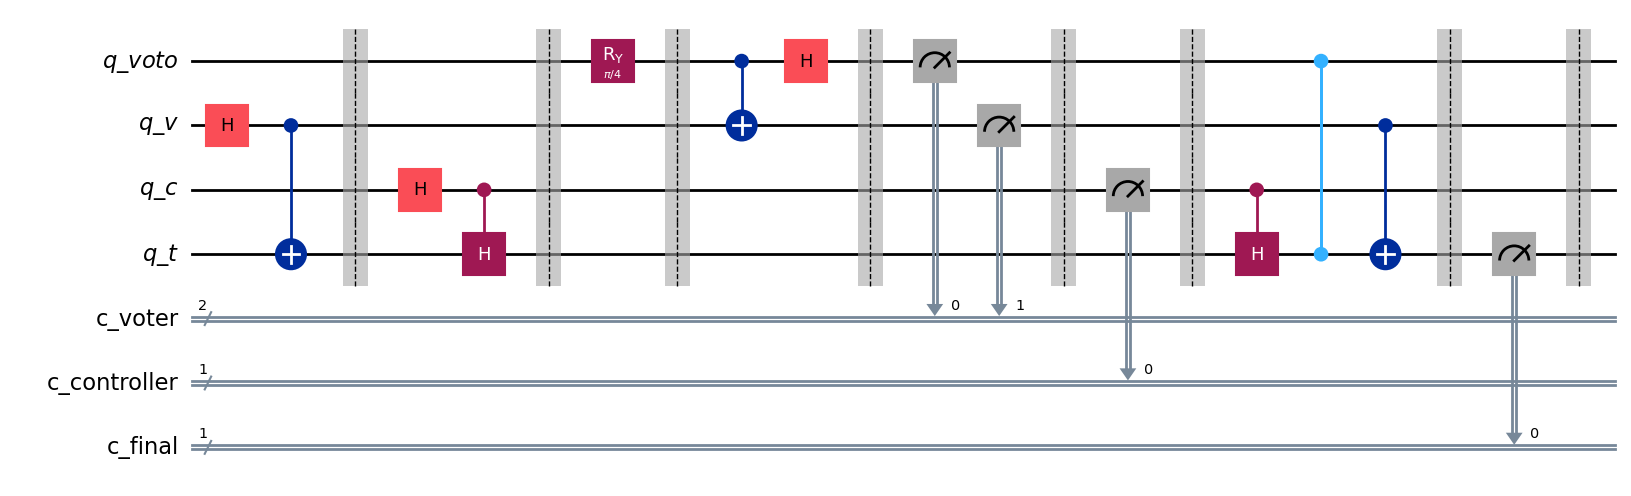


✗ Error: [Errno 2] No such file or directory: '/home/dario/Desktop/uni/tfg/quantum_voting_circuit_ch.png'


In [ ]:
# ============================================================================
# VISUALIZAR EL CIRCUITO
# ============================================================================

print("\n" + "="*80)
print("VISUALIZACIÓN DEL CIRCUITO")
print("="*80)

try:
    # Dibujar el circuito
    circuit_diagram = circuit.draw(output='mpl', fold=80)
    display(circuit_diagram)
    if circuit_diagram is not None:
        circuit_diagram.set_size_inches(14, 10)
        circuit_diagram.tight_layout()
        circuit_diagram.savefig('/home/dario/Desktop/uni/tfg/quantum_voting_circuit_ch.png', dpi=300, bbox_inches='tight')

    print(f"\n✓ Circuito guardado")
    print(f"  Qubits: {circuit.num_qubits}, Bits clásicos: {circuit.num_clbits}")
    print(f"  Puertas: {circuit.size()}, Profundidad: {circuit.depth()}")
except Exception as e:
    print(f"\n✗ Error: {e}")

## Sección 10: Ejecutar Circuito y Contar Resultados en Simulador

In [ ]:
# ============================================================================
# EJECUTAR Y CONTAR RESULTADOS
# ============================================================================

print("\n" + "="*80)
print("8192 EJECUCIONES EN SIMULADOR (VARIANTE CH)")
print("="*80)

# Crear simulador
simulator = AerSimulator()

# Descomponer el circuito para asegurar compatibilidad con Aer
decomposed_circuit = circuit.decompose()

# Ejecutar
job = simulator.run(decomposed_circuit, shots=8192)
result = job.result()
counts = result.get_counts(decomposed_circuit)

# Contar votos
count_0 = 0
count_1 = 0

for bitstring, count in counts.items():
    parts = bitstring.split()
    if len(parts) >= 1:
        final_bit = parts[0]
        if final_bit == '0':
            count_0 += count
        elif final_bit == '1':
            count_1 += count

print(f"\nResultados de los Votos (Variante CH):")
print(f"  Votos para 0: {count_0} ({count_0/8192*100:.1f}%)")
print(f"  Votos para 1: {count_1} ({count_1/8192*100:.1f}%)")
print(f"\n✓ Protocolo QSS con Hadamard Controlada ejecutado correctamente")


8192 EJECUCIONES EN SIMULADOR (VARIANTE CH)

Resultados de los Votos (Variante CH):
  Votos para 0: 6988 (85.3%)
  Votos para 1: 1204 (14.7%)

✓ Protocolo QSS con Hadamard Controlada ejecutado correctamente


Visualizando histograma de la simulación Aer...


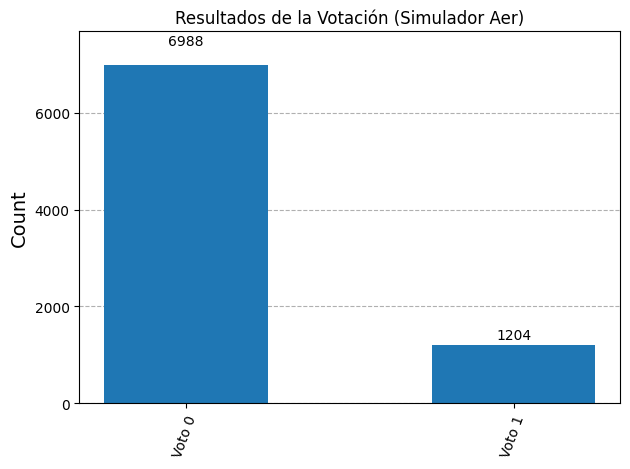

In [ ]:
# ============================================================================
# VISUALIZAR RESULTADOS DE LA SIMULACIÓN
# ============================================================================

vote_results = {'Voto 0': count_0, 'Voto 1': count_1}

print("Visualizando histograma de la simulación Aer...")
plot_histogram(vote_results, title="Resultados de la Votación (Simulador Aer)")

## Sección 11: Ejecutar en IBM Quantum

Ejecución del circuito variante CH en un backend real de IBM Quantum.

In [ ]:
# ============================================================================
# EJECUTAR EN IBM QUANTUM
# ============================================================================

from qiskit_ibm_runtime import QiskitRuntimeService, Sampler
from qiskit import transpile

print("\n" + "="*80)
print("EJECUCIÓN EN IBM QUANTUM (ibm_fez) - VARIANTE CH")
print("="*80)

# Conectar a IBM Quantum
print("\n1. Conectando a IBM Quantum...")
service = QiskitRuntimeService(channel="ibm_quantum_platform", token="PONER AQUÍ TOKEN PARA LA EJECUCIÓN CON IBMQ")
print("✓ Conectado")

# Obtener el backend
print("\n2. Obteniendo backend ibm_fez...")
backend = service.backend("ibm_fez")
print(f"✓ Backend: {backend.name}")
print(f"  Qubits: {backend.num_qubits}")

# Transpiler el circuito para el hardware
print("\n3. Transpilando circuito para ibm_fez...")
transpiled_circuit = transpile(circuit, backend=backend, optimization_level=1)
print(f"✓ Circuito transpilado")

# Ejecutar en IBM Quantum usando Sampler
print("\n4. Enviando circuito a IBM Quantum (8192 shots)...")
sampler = Sampler(backend)
job = sampler.run([transpiled_circuit], shots=8192)
print(f"✓ Job enviado: {job.job_id()}")

# Esperar resultados
print("\n5. Esperando resultados...")
result = job.result()
print("✓ Resultados obtenidos")

# Extraer resultados
pub_result = result[0]

# Extraer mediciones de ambos registros clásicos
final_measurements = pub_result.data.c_final.array.flatten()
controller_measurements = pub_result.data.c_controller.array.flatten()

# Contar votos usando numpy
unique_values, count_values = np.unique(final_measurements, return_counts=True)

counts_ibm = {}
for bit_val, count in zip(unique_values, count_values):
    counts_ibm[str(bit_val)] = int(count)

# Contar votos
count_0_ibm = counts_ibm.get('0', 0)
count_1_ibm = counts_ibm.get('1', 0)

print(f"\nResultados en IBM Quantum (Variante CH con Corrección Hadamard):")
print(f"  Votos para 0: {count_0_ibm} ({count_0_ibm/8192*100:.1f}%)")
print(f"  Votos para 1: {count_1_ibm} ({count_1_ibm/8192*100:.1f}%)")

print(f"\nComparación Simulador vs IBM Quantum (Variante CH):")
print(f"  Simulador:    0: {count_0/8192*100:.1f}%,  1: {count_1/8192*100:.1f}%")
print(f"  IBM Quantum:  0: {count_0_ibm/8192*100:.1f}%,  1: {count_1_ibm/8192*100:.1f}%")

qiskit_runtime_service._discover_account:WARNING:2026-06-11 14:49:02,721: Loading account with the given token. A saved account will not be used.



EJECUCIÓN EN IBM QUANTUM (ibm_fez) - VARIANTE CH

1. Conectando a IBM Quantum...


qiskit_runtime_service.__init__:WARNING:2026-06-11 14:49:06,229: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-11 14:49:06,234: Using instance: open-instance, plan: open


✓ Conectado

2. Obteniendo backend ibm_fez...
✓ Backend: ibm_fez
  Qubits: 156

3. Transpilando circuito para ibm_fez...
✓ Circuito transpilado

4. Enviando circuito a IBM Quantum (8192 shots)...
✓ Job enviado: d8lclpj2d42s73cb8eog

5. Esperando resultados...
✓ Resultados obtenidos

Resultados en IBM Quantum (Variante CH con Corrección Hadamard):
  Votos para 0: 6314 (77.1%)
  Votos para 1: 1878 (22.9%)

Comparación Simulador vs IBM Quantum (Variante CH):
  Simulador:    0: 85.3%,  1: 14.7%
  IBM Quantum:  0: 77.1%,  1: 22.9%


Visualizando histograma de la simulación Aer...


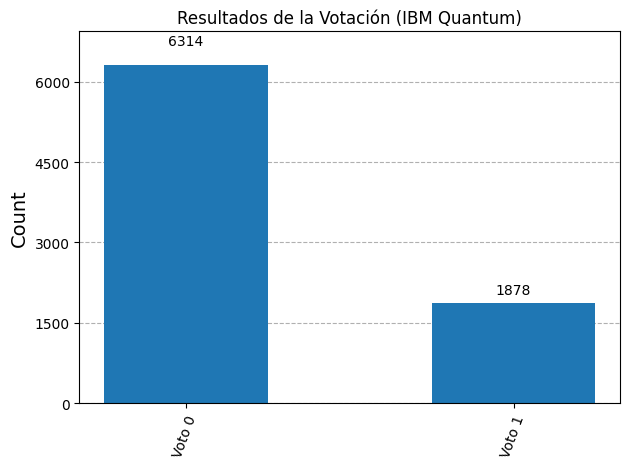

In [ ]:
# ============================================================================
# VISUALIZAR RESULTADOS DE IBM QUANTUM
# ============================================================================
ibm_results = {'Voto 0': count_0_ibm, 'Voto 1': count_1_ibm}

print("Visualizando histograma de la simulación Aer...")
plot_histogram(ibm_results, title="Resultados de la Votación (IBM Quantum)")